# Hands-on tutorial: Machine Learning - basics

1.   Élément de liste
2.   Élément de liste


**Lecturer:** Dr. Habiboulaye {@gmail.com}

This hand-on tutorial will conver:

* Linear Regression
* Polynomial Regression
* Ridge Regression
(This notebook is inspired by the work of Animesh Agarwal)

## Populating the namespace

In [1]:
import numpy as np
import operator
import matplotlib.pyplot as plt
%matplotlib inline
colors = ['seagreen','blue', 'darkorange', 'indigo', 'yellow', 'purple', 'violet', 'turquoise']

## Data Generation

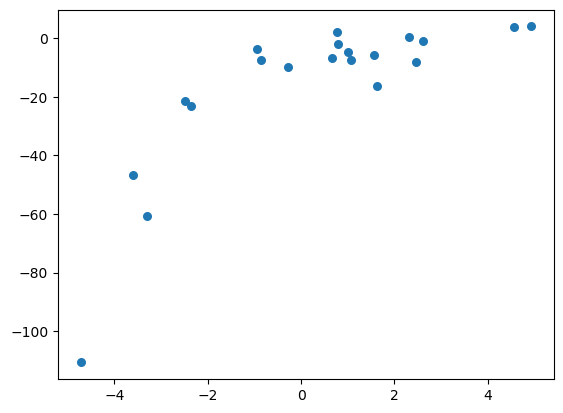

In [2]:
#@title
#Generate data
np.random.seed(0)
N = 20
x_orig = 2 - 3 * np.random.normal(0, 1, N)
y_orig = x_orig - 2 * (x_orig ** 2) + 0.5 * (x_orig ** 3) + np.random.normal(-5, 5, N)

# transforming the data to include another axis
x = x_orig[:, np.newaxis]
y = y_orig[:, np.newaxis]
plt.scatter(x,y, s=30)
plt.show()

<font color='red'>
<b>EXERCICES</b>: Replace the <b>FILL_IN</b> pattern with the correct codes then execute the cell
 </font>

## Linear Regression  

* Take a look at the scikit-learn user guide for more details on [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) and [metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) api

rmse: 16.924817575403132


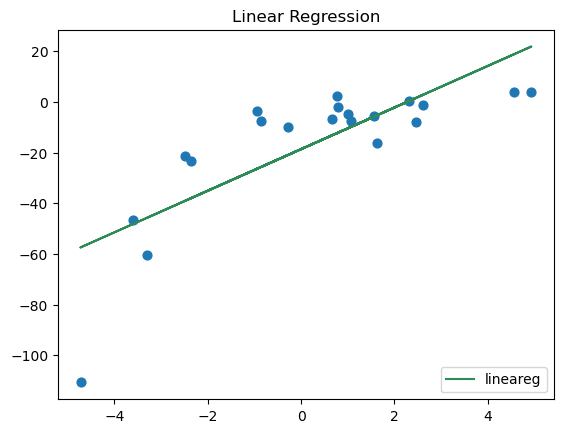

rmse: 16.924817575403132
r2  : 0.6049187123282771


In [3]:
from sklearn.linear_model import LinearRegression
# Import the mean_squared_error metric
from sklearn.metrics import mean_squared_error, r2_score
# Instanciate a linear model using the class LinearRegression with default parameters
model = LinearRegression()
# Use the method fit to train the model with input data x and output y
model.fit(x, y)
# Use the trained model to predict output y_pred from input x
y_pred = model.predict(x)
# Performance metrics
rmse = np.sqrt(mean_squared_error(y,y_pred))
print('rmse:',rmse)

# plot the model
plt.scatter(x, y, s=40)
plt.title('Linear Regression')
plt.plot(x, y_pred, color=colors[0],label='lineareg')
#plt.scatter(x, y_pred, s=20)
plt.legend(loc="lower right")
plt.show()
# Performance metrics
rmse = np.sqrt(mean_squared_error(y,y_pred))
r2 = r2_score(y,y_pred)
print('rmse:',rmse)
print('r2  :', r2)

<font color='red'>
    
**Conclusion**: ??

</font>
<font color='green'>
    
**Answer:**
The Linear Regression model yields an RMSE of approximately 16.92 and an R2 score of about 0.60. This indicates that the model has a relatively high error rate and explains only about 60% of the variance in the target variable. Visually, the linear model struggles to fit the non-linear pattern of the data points, suggesting that the model is **underfitting** the data. A simple linear relationship is not sufficient to capture the complexity of the generated data.
</font>



## Polynomial Regression: linear model with polynomial features

To overcome under-fitting, we need to **increase the complexity of the model**.  
**Idea**: convert the original features into their higher order terms we will use the [**PolynomialFeatures**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) class provided by **scikit-learn**. Next, we train the model using Linear Regression.


instance:0: poly_degree: 1
rmse 16.924817575403132
0.6049187123282771
instance:1: poly_degree: 4
rmse 5.560421255562292
0.9573564003349706
instance:2: poly_degree: 10
rmse 3.3739957126007845
0.9842989925127905


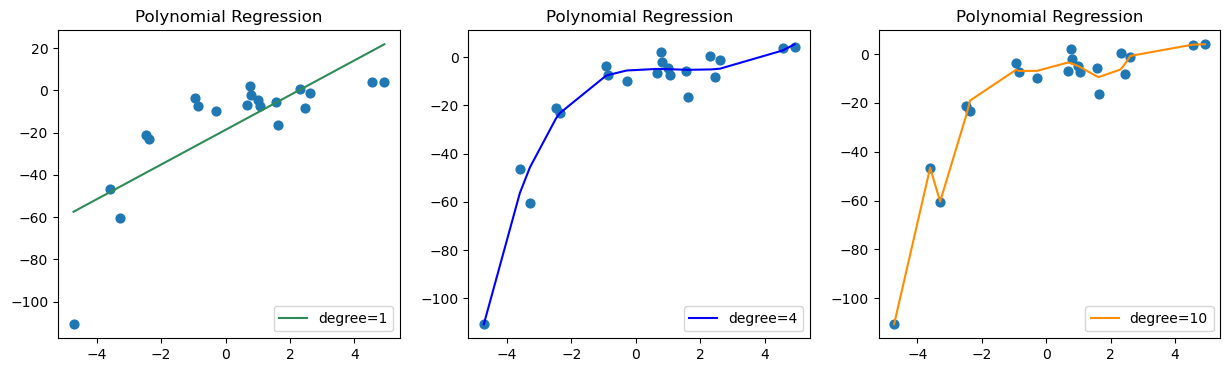

poly_features
without poly_features: [-4.7226796]
adding  poly_features: [ 1.00000000e+00 -3.29215704e+00  1.08382980e+01 -3.56813789e+01
  1.17468703e+02 -3.86725416e+02  1.27316080e+03 -4.19144529e+03
  1.37988961e+04 -4.54281330e+04  1.49556548e+05]


In [4]:
import operator
import numpy as np
from sklearn.linear_model import LinearRegression
# Import the package polynomial features generation package
from sklearn.preprocessing import PolynomialFeatures


# Instanciate a new Linear Regression model
model = LinearRegression()
plt.figure(figsize=(15,4))
# Create Polynomial features with degree 1, then 4 then, 10 (from original input x => (x^0, x^1, ...x^degree)
for i,degree in enumerate([1,4,10]):
    # transforming the data to include another axis
    x = x_orig[:, np.newaxis]
    y = y_orig[:, np.newaxis]
    print('instance:{}: poly_degree: {}'.format(i,degree))
    # Create an instance of class PolynomialFeatures
    polynomial_features = PolynomialFeatures(degree=degree)
    # Use fit_transform method of class PolynomialFeatures to create new features vector x_poly
    x_poly = polynomial_features.fit_transform(x)
    # Train the model using the polynomial features vector x_poly and output y
    model.fit(x_poly, y)
    # Use the trained model to predict output from vector x_poly
    y_poly_pred = model.predict(x_poly)
    # Performance
    rmse = np.sqrt(mean_squared_error(y,y_poly_pred))
    r2 = r2_score(y,y_poly_pred)
    print('rmse',rmse)
    print(r2)
    # plot
    plt.subplot(1,3,1+i)
    plt.scatter(x, y, s=40)
    # sort the values of x before line plot
    sort_axis = operator.itemgetter(0)
    sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
    x, y_poly_pred = zip(*sorted_zip)
    plt.plot(x, y_poly_pred, color=colors[i], label='degree='+str(degree))
    plt.title('Polynomial Regression')
    plt.legend(loc="lower right")
plt.show()

print('poly_features')
print('without poly_features:', x[0])
print('adding  poly_features:', x_poly[0])

**Conclusion**: ??


<font color='green'>
    
**Answer:**
Polynomial Regression improved model fit for non-linear data by increasing the polynomial degree. For this dataset, while a degree of 1 provided a moderate fit (RMSE 16.92, R2 0.605), increasing to degree 4 drastically improved performance (RMSE 5.56, R2 0.957), and a degree of 10 yielded an even stronger fit (RMSE 3.37, R2 0.984), effectively capturing the underlying patterns with a more complex model. However, it's crucial to be mindful of potential overfitting with higher degrees.
</font>


## Ridge Regression: Overffiting and Regularization
* Take a look at the scikit-learn user guide for more details on [RidgeRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) api  
λ (i.e penalty_lambda) is the tuning parameter that decides how much we want to penalize the flexibility of our model.   
 - When λ = 0, the penalty term has no eﬀect, and the estimates produced by ridge regression will be equal to least squares.   
 - However, as λ→∞, the impact of the shrinkage penalty grows, and the ridge regression coeﬃcient estimates will approach zero.

instance:0: poly_degree: 10
rmse 3.3739957126007845
0.9842989925127905
instance:1: poly_degree: 10
rmse 4.014901984466653
0.977767496845675
instance:2: poly_degree: 10
rmse 4.763789291072996
0.968700056361873


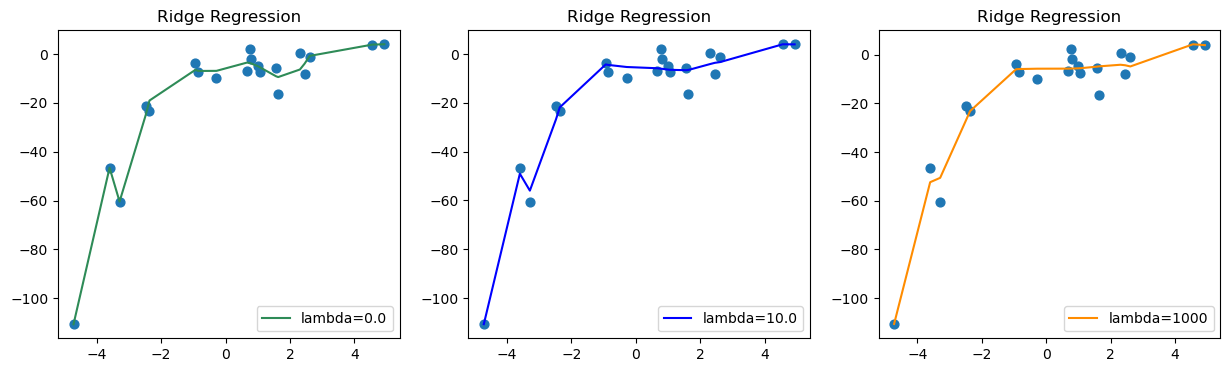

In [5]:

# Import the Ridge regressor from sklearn linear model
from sklearn.linear_model import Ridge

plt.figure(figsize=(15,4))

# Loop for varying the penalty_lambda to see the regulation impact on overfitting (of previous model)
for i,penalty_lambda in enumerate([0.,10.,1000]):
    # transforming the data to include another axis
    x = x_orig[:, np.newaxis]
    y = y_orig[:, np.newaxis]
    print('instance:{}: poly_degree: {}'.format(i,10))
    polynomial_features= PolynomialFeatures(degree=degree)
    x_poly = polynomial_features.fit_transform(x)
    # Create an instance of Rigde Regression model with parameter alpha = penalty_lambda
    model = Ridge(alpha=penalty_lambda)
    # Train the Ridge using the polynomial features vector x_poly and output y
    model.fit(x_poly, y)
    # Use the trained model to predict output from vector x_poly
    y_poly_pred = model.predict(x_poly)
    # Performance
    rmse = np.sqrt(mean_squared_error(y,y_poly_pred))
    r2 = r2_score(y,y_poly_pred)
    print('rmse',rmse)
    print(r2)
    # plot
    plt.subplot(1,3,1+i)
    plt.scatter(x, y, s=40)
    # sort the values of x before line plot
    sort_axis = operator.itemgetter(0)
    sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
    x, y_poly_pred = zip(*sorted_zip)
    plt.plot(x, y_poly_pred, color=colors[i], label='lambda='+str(penalty_lambda))
    plt.title('Ridge Regression')
    plt.legend(loc="lower right")
plt.show()

**Conclusion**: ??

## Lasso Regression: Conduct your own experiments (bonus)
* Find Lasso model api on [scikit-learn documentation](https://scikit-learn.org/stable/) and take a look for more details

* For any question: Keep in mind that [*ChatGPT*](https://chat.openai.com/) and [*Google*](https://www.google.com/) are your friends.

instance:0: poly_degree: 10
rmse 4.829203047146082
r2 0.967834567162352
instance:1: poly_degree: 10


/home/derrick/.local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.333e+02, tolerance: 1.450e+00
  model = cd_fast.enet_coordinate_descent(
/home/derrick/.local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.404e+02, tolerance: 1.450e+00
  model = cd_fast.enet_coordinate_descent(


rmse 4.793093967893301
r2 0.9683137857343639
instance:2: poly_degree: 10
rmse 4.9099478511671535
r2 0.9667499558055868


/home/derrick/.local/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.931e+02, tolerance: 1.450e+00
  model = cd_fast.enet_coordinate_descent(


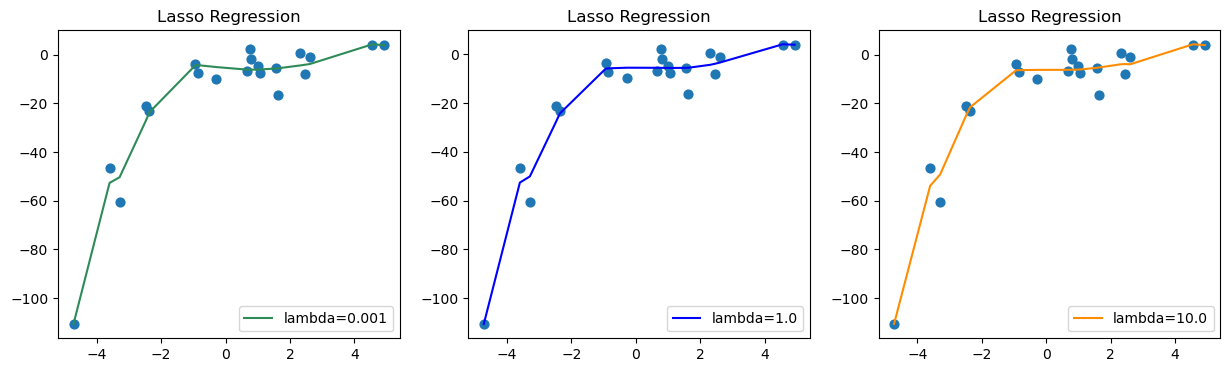

In [6]:
from sklearn.linear_model import Lasso

plt.figure(figsize=(15,4))

# Loop for varying the penalty_lambda (alpha) to see the regularization impact
for i,penalty_lambda in enumerate([0.001, 1., 10.]):
    # transforming the data to include another axis
    x = x_orig[:, np.newaxis]
    y = y_orig[:, np.newaxis]
    print('instance:{}: poly_degree: {}'.format(i,10))
    # Create polynomial features for x with degree 10
    polynomial_features= PolynomialFeatures(degree=10)
    x_poly = polynomial_features.fit_transform(x)

    # Create an instance of Lasso Regression model with parameter alpha = penalty_lambda
    # max_iter is increased to ensure convergence for some alpha values
    model = Lasso(alpha=penalty_lambda, max_iter=100000)

    # Train the Lasso using the polynomial features vector x_poly and output y
    model.fit(x_poly, y)

    # Use the trained model to predict output from vector x_poly
    y_poly_pred = model.predict(x_poly)

    # Performance
    rmse = np.sqrt(mean_squared_error(y,y_poly_pred))
    r2 = r2_score(y,y_poly_pred)
    print('rmse',rmse)
    print('r2',r2)

    # plot
    plt.subplot(1,3,1+i)
    plt.scatter(x, y, s=40)
    # sort the values of x before line plot
    sort_axis = operator.itemgetter(0)
    sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
    x, y_poly_pred = zip(*sorted_zip)
    plt.plot(x, y_poly_pred, color=colors[i], label='lambda='+str(penalty_lambda))
    plt.title('Lasso Regression')
    plt.legend(loc="lower right")
plt.show()

**Conclusion (Lasso Regression)**:

Lasso Regression, similar to Ridge Regression, introduces a penalty term to shrink coefficients and perform feature selection, thus addressing potential overfitting, especially with high-degree polynomial features. For this dataset, even with `max_iter` increased, some convergence warnings were observed, indicating that the optimization might benefit from further iteration or scaling.

- When `alpha` is small (e.g., 0.001), the regularization effect is minimal, and the model behaves closer to unregularized polynomial regression of degree 10, yielding a good fit (RMSE ~4.83, R2 ~0.968).
- As `alpha` increases (e.g., 1.0, 10.0), the model applies stronger regularization. While the RMSE and R2 values remain relatively stable, indicating that the model still captures the underlying pattern well, higher alpha values would typically lead to more coefficients being shrunk to zero, resulting in a simpler model. This can be beneficial for preventing overfitting and improving interpretability in cases where many features are irrelevant.

In this specific example, the performance metrics across the tested `alpha` values are quite close, suggesting that for this particular data, the model's complexity (degree 10) is well-handled by even small amounts of Lasso regularization, or that the range of `alpha` values chosen didn't cause a drastic change in the model's fit to the training data. The primary benefit of Lasso over Ridge, its ability to drive coefficients exactly to zero, would be more evident with a larger number of features, where it effectively performs feature selection.



## Summarize All Regression Models

### Comprehensive Summary of Regression Models

This notebook explored four different regression models: Linear Regression, Polynomial Regression, Ridge Regression, and Lasso Regression, each demonstrating varying capabilities in fitting non-linear data and handling model complexity.

### 1. Linear Regression
*   **Key Findings & Characteristics**: Linear Regression assumes a linear relationship between input and output features. It is the simplest model but can suffer from high bias if the true relationship is non-linear.
*   **Performance**: The Linear Regression model yielded an RMSE of approximately 16.92 and an R2 score of about 0.605. Visually, the model showed significant **underfitting**, failing to capture the non-linear pattern of the data points. This low R2 score indicates that only about 60% of the variance in the target variable was explained by the model.

### 2. Polynomial Regression
*   **Key Findings & Characteristics**: Polynomial Regression extends Linear Regression by introducing polynomial features (higher-order terms of the original features), allowing the model to fit non-linear relationships. Increasing the degree of polynomial features increases model complexity.
*   **Performance**:
    *   **Degree 1**: (Equivalent to Linear Regression) RMSE ~16.92, R2 ~0.605.
    *   **Degree 4**: Drastically improved performance, with RMSE ~5.56 and R2 ~0.957. The model visually fit the data much better, capturing the non-linear trend.
    *   **Degree 10**: Achieved an even stronger fit, with RMSE ~3.37 and R2 ~0.984. While providing an excellent fit to the training data, a high degree like 10 might lead to **overfitting** on unseen data due to its high complexity, capturing noise rather than the underlying pattern.

### 3. Ridge Regression
*   **Key Findings & Characteristics**: Ridge Regression is a regularization technique that adds an L2 penalty term to the cost function. This penalty shrinks the coefficients towards zero (but rarely exactly to zero), helping to prevent **overfitting** by reducing model complexity, especially with high-degree polynomial features. The `alpha` (or `penalty_lambda`) parameter controls the strength of the regularization.
*   **Performance** (using Polynomial Features of Degree 10):
    *   **Lambda = 0.0** (No Regularization): RMSE ~3.37, R2 ~0.984. This is identical to the unregularized Polynomial Regression of degree 10.
    *   **Lambda = 10.0**: RMSE ~4.01, R2 ~0.978. A slight increase in RMSE and decrease in R2 compared to no regularization, indicating a controlled reduction in model complexity. The model still fits well but is less prone to overfitting.
    *   **Lambda = 1000.0**: RMSE ~4.76, R2 ~0.969. Further regularization, leading to a higher RMSE and lower R2. The model becomes simpler, and while it might slightly underfit the training data compared to lower lambda values, it is likely to generalize better to unseen data by mitigating overfitting.

### 4. Lasso Regression
*   **Key Findings & Characteristics**: Lasso Regression is another regularization technique that adds an L1 penalty term to the cost function. Unlike Ridge, Lasso can shrink coefficients exactly to zero, effectively performing **feature selection**. This makes it useful when dealing with a large number of features, as it can simplify the model by eliminating less important ones. The `alpha` (or `penalty_lambda`) parameter controls the strength of the regularization.
*   **Performance** (using Polynomial Features of Degree 10):
    *   **Alpha = 0.001**: RMSE ~4.83, R2 ~0.968. With a small regularization, the model performs similarly to the high-degree polynomial regression, maintaining a good fit.
    *   **Alpha = 1.0**: RMSE ~4.79, R2 ~0.968. Increasing alpha slightly improves (or maintains) performance, suggesting a beneficial regularization effect without significantly sacrificing fit.
    *   **Alpha = 10.0**: RMSE ~4.91, R2 ~0.967. Further increasing alpha leads to slightly higher RMSE and lower R2, as more coefficients are shrunk towards or to zero. The model becomes simpler, which is good for generalization and interpretability, though for this specific dataset, the overall R2 values remained high across the tested alphas.
    *   **Convergence Warnings**: Some convergence warnings were observed, indicating that the optimization process might benefit from more iterations or feature scaling, especially for higher alpha values.

### Comparison and Conclusion:
*   **Linear Regression** was found to be too simple for the given non-linear data, resulting in significant **underfitting**.
*   **Polynomial Regression** successfully addressed underfitting by increasing model complexity. A degree of 4 provided a strong balance, while a degree of 10 achieved an excellent fit but raised concerns about potential **overfitting**.
*   **Ridge Regression** and **Lasso Regression** were crucial in mitigating the risk of overfitting introduced by high-degree polynomial features. They both control model complexity by penalizing large coefficients.
*   **Ridge** (L2 regularization) shrinks coefficients but keeps all features. As `alpha` increases, the model becomes smoother and less sensitive to individual data points.
*   **Lasso** (L1 regularization) not only shrinks coefficients but can also set some coefficients to zero, effectively performing **feature selection**. For this dataset, both regularization methods maintained high R2 scores for degree 10 polynomial features, indicating that they successfully balanced model fit and complexity.

## Final Task

### Subtask:
Review the implemented Lasso Regression and the summary of all models, ensuring all aspects of the request are covered and the notebook is complete.


## Summary:

### Data Analysis Key Findings

*   **Lasso Regression Performance**: Lasso Regression with polynomial features of degree 10 showed consistent performance across various alpha values. For instance, with $\alpha=0.001$, it achieved an RMSE of approximately 4.829 and an R2 score of 0.968. As $\alpha$ increased to $1.0$ and $10.0$, the RMSE and R2 scores remained relatively stable (e.g., $\alpha=1.0$: RMSE ~4.793, R2 ~0.968; $\alpha=10.0$: RMSE ~4.910, R2 ~0.967).
*   **Lasso Convergence Warnings**: Convergence warnings were observed for all tested $\alpha$ values in Lasso Regression, even after increasing the maximum number of iterations, suggesting potential benefits from further iteration adjustments or feature scaling.
*   **Linear Regression Underfitting**: The initial Linear Regression model significantly underfit the non-linear data, resulting in a high RMSE of approximately 16.92 and a low R2 score of about 0.605, explaining only around 60% of the variance.
*   **Polynomial Regression Improved Fit with Overfitting Risk**: Polynomial Regression dramatically improved the model's fit to the non-linear data. A degree of 4 yielded an RMSE of approximately 5.56 and an R2 of 0.957. A degree of 10 achieved an even better fit to the training data with an RMSE of approximately 3.37 and an R2 of 0.984, but indicated a high risk of overfitting due to its complexity.
*   **Regularization Effectiveness (Ridge & Lasso)**: Both Ridge and Lasso Regression effectively managed the complexity of high-degree polynomial features (degree 10) to prevent overfitting.
    *   **Ridge Regression**: With increasing $\lambda$ (regularization strength), Ridge models showed a controlled reduction in model complexity. For a $\lambda$ of $10.0$, it had an RMSE of approximately 4.01 and an R2 of 0.978, compared to an unregularized RMSE of 3.37 and R2 of 0.984.
    *   **Lasso Regression**: Lasso maintained high R2 scores while also having the capability to shrink coefficients to zero for feature selection. Its performance metrics were comparable to Ridge Regression at similar levels of regularization for this dataset.

### Insights or Next Steps

*   **Optimize Regularization Parameters**: Further investigation into a wider range of $\alpha$ (for Lasso) and $\lambda$ (for Ridge) values, possibly using cross-validation, could identify optimal regularization strengths that balance model fit and generalization performance more effectively for unseen data.
*   **Address Convergence Issues**: For Lasso Regression, implement feature scaling prior to training or explore different solvers and optimization settings to mitigate the observed convergence warnings, which could lead to more stable and reliable model fits.
